In [28]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import norm

In [29]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVECSV = False

### Data Preparation and Preprocessing

In [30]:
# import dataframe with both real data and simulation data
with open("simu1_data/simu1_behav.pkl", "rb") as inp:
    df = pickle.load(inp)
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547


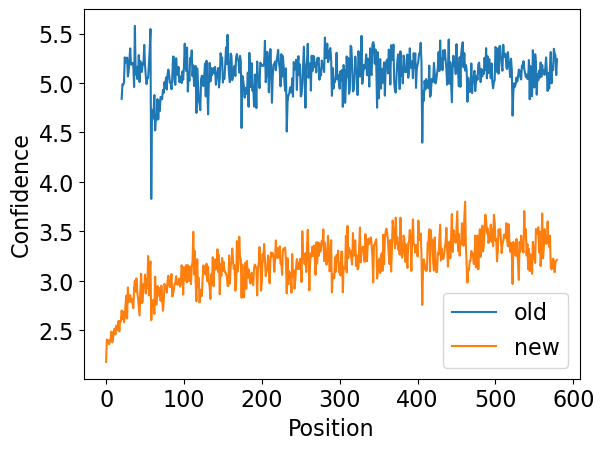

In [32]:
old_conf_pos = df.query("old == True").groupby("position").confidence.mean()
old_pos = np.unique(df.query("old == True").position.values)
new_conf_pos = df.query("old == False").groupby("position").confidence.mean()
new_pos = np.unique(df.query("old == False").position.values)

plt.plot(old_pos, old_conf_pos, label="old")
plt.plot(new_pos, new_conf_pos, label="new")
plt.xlabel("Position")
plt.ylabel("Confidence")
plt.legend()
plt.show()

In [4]:
# calculate the rolling category length
rolling_window = 9
category_label_dummies = df["category_label"].str.get_dummies()
category_label_dummies.columns = ["cl_" + col for col in category_label_dummies.columns]
category_label_dummies_events = pd.concat([df, category_label_dummies], axis=1)  # record the occurrence of every cat label
cl_rolling_sum = category_label_dummies_events.groupby("subject_ID").rolling(rolling_window, min_periods=1, on="position")[category_label_dummies.columns].sum().reset_index()
df_rollcat = df.merge(cl_rolling_sum, on=["subject_ID", "position"])
df["roll_cat_label_length"] = df_rollcat.apply(lambda x: x["cl_" + x["category_label"]], axis=1)  # how many cat within 9 window
df["roll_cat_label_length"] = df["roll_cat_label_length"] - 1  # how many cat in previous 8 window, not include self

# add rolling category length level
df["roll_cat_len_level"] = pd.cut(x=df.roll_cat_label_length, bins=[0, 2, np.inf], right=False, include_lowest=True, labels=["0-1", ">=2"]).astype("str")
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session,roll_cat_label_length,roll_cat_len_level
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0,0.0,0-1
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0,0.0,0-1
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0,0.0,0-1
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0,1.0,0-1
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0,0.0,0-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547,2.0,>=2
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547,0.0,0-1
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547,3.0,>=2
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547,0.0,0-1


In [5]:
# add log and log lag bin
df["log_lag"] = np.log(df["lag"])
df["log_lag_bin"] = pd.cut(df["log_lag"], np.arange(df["log_lag"].max() + 1), labels=False, right=False)
df

/home1/beigejin/.conda/envs/CMR_IA/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session,roll_cat_label_length,roll_cat_len_level,log_lag,log_lag_bin
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0,0.0,0-1,-inf,NaN
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0,0.0,0-1,-inf,NaN
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0,0.0,0-1,-inf,NaN
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0,1.0,0-1,-inf,NaN
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0,0.0,0-1,-inf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547,2.0,>=2,3.610918,3.0
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547,0.0,0-1,4.744932,4.0
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547,3.0,>=2,3.178054,3.0
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547,0.0,0-1,3.713572,3.0


In [6]:
# construct local FAR
old_vec = df.old.to_numpy()
log_lag_bin_vec = df.log_lag_bin.to_numpy()
position_vec = df.position.to_numpy()
log_lag_bin_newpre_lst = []
log_lag_bin_newpost_lst = []
for i in range(len(df)):
    if position_vec[i] > 0:
        if old_vec[i] == False and old_vec[i - 1] == True:
            log_lag_bin_newpre_lst.append(log_lag_bin_vec[i - 1])
        else:
            log_lag_bin_newpre_lst.append("N")
    else:
        log_lag_bin_newpre_lst.append("N")

    if position_vec[i] < np.max(position_vec):
        if old_vec[i] == False and old_vec[i + 1] == True:
            log_lag_bin_newpost_lst.append(log_lag_bin_vec[i + 1])
        else:
            log_lag_bin_newpost_lst.append("N")
    else:
        log_lag_bin_newpost_lst.append("N")

df["log_lag_bin_newpre"] = log_lag_bin_newpre_lst
df["log_lag_bin_newpost"] = log_lag_bin_newpost_lst
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,curr_cat_length,curr_cat_label_length,itemno,session,roll_cat_label_length,roll_cat_len_level,log_lag,log_lag_bin,log_lag_bin_newpre,log_lag_bin_newpost
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,NaN,0,53,0,0.0,0-1,-inf,NaN,N,N
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,NaN,0,26,0,0.0,0-1,-inf,NaN,N,N
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,NaN,0,33,0,0.0,0-1,-inf,NaN,N,N
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,NaN,1,151,0,1.0,0-1,-inf,NaN,N,N
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,NaN,0,187,0,0.0,0-1,-inf,NaN,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,18.0,18,60,547,2.0,>=2,3.610918,3.0,N,N
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,23.0,23,10,547,0.0,0-1,4.744932,4.0,N,N
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,19.0,19,265,547,3.0,>=2,3.178054,3.0,N,N
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,NaN,23,213,547,0.0,0-1,3.713572,3.0,N,N


1~7 -> 1(0,1), 8~20 -> 8(2), 21~54 -> 21(3), 55~148 -> 55(4), >=149 -> 149(5)

In [7]:
df["log_lag_bin"] = df.apply(lambda x: 0 if x["log_lag_bin"] == 1 else x["log_lag_bin"], axis=1)
df["log_lag_bin"] = df.apply(lambda x: 5 if x["log_lag_bin"] > 5 else x["log_lag_bin"], axis=1)
df["log_lag_bin_newpre"] = df.apply(lambda x: 0 if x["log_lag_bin_newpre"] == 1 else x["log_lag_bin_newpre"], axis=1)
df["log_lag_bin_newpost"] = df.apply(lambda x: 0 if x["log_lag_bin_newpost"] == 1 else x["log_lag_bin_newpost"], axis=1)
# distribute items into bins
log_lag_bins = [0, 2, 3, 4, 5]
for bin in log_lag_bins:
    col_name = "log_lag_bin_" + str(bin)
    df[col_name] = (df.log_lag_bin == bin) | (df.log_lag_bin_newpre == bin) | (df.log_lag_bin_newpost == bin)
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,roll_cat_len_level,log_lag,log_lag_bin,log_lag_bin_newpre,log_lag_bin_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5
0,1514.875,0,CHICKEN,0,Uncategorized,1.0,FarmAnimals,0,False,0.0,...,0-1,-inf,NaN,N,N,False,False,False,False,False
1,853.505,0,BLUEBERRY,0,Uncategorized,1.0,Fruit,1,False,0.0,...,0-1,-inf,NaN,N,N,False,False,False,False,False
2,731.040,0,BUS,0,Uncategorized,1.0,Vehicles,2,False,0.0,...,0-1,-inf,NaN,N,N,False,False,False,False,False
3,848.955,0,LEMON,0,Uncategorized,1.0,Fruit,3,False,0.0,...,0-1,-inf,NaN,N,N,False,False,False,False,False
4,643.880,0,OYSTER,0,Uncategorized,1.0,OceanAnimals,4,False,0.0,...,0-1,-inf,NaN,N,N,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,>=2,3.610918,3.0,N,N,False,False,True,False,False
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,0-1,4.744932,4.0,N,N,False,False,False,True,False
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,>=2,3.178054,3.0,N,N,False,False,True,False,False
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,0-1,3.713572,3.0,N,N,False,False,True,False,False


In [8]:
df.groupby(["old", "log_lag_bin", "roll_cat_len_level"]).yes.count()

old   log_lag_bin  roll_cat_len_level
True  0.0          0-1                    9479
                   >=2                   18654
      2.0          0-1                   23905
                   >=2                    9054
      3.0          0-1                   39599
                   >=2                    4337
      4.0          0-1                   29760
                   >=2                    1867
      5.0          0-1                    6719
                   >=2                     291
Name: yes, dtype: int64

<Axes: xlabel='lag', ylabel='Count'>

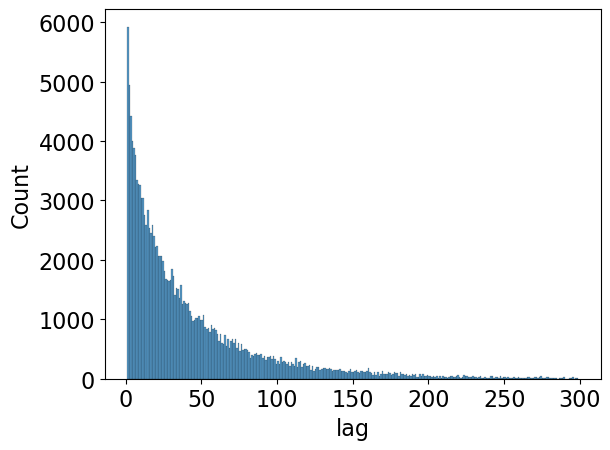

In [9]:
# plot the distribution of lags in df
fig, ax = plt.subplots()
sns.histplot(df.query("lag > 0"), x="lag", ax=ax, bins=np.arange(1, 300))

### Lag Group and Roll Cat

In [10]:
df = df.query("position >=20")
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,roll_cat_len_level,log_lag,log_lag_bin,log_lag_bin_newpre,log_lag_bin_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5
20,812.780,0,FUDGE,0,Uncategorized,1.0,Desserts,20,False,0.0,...,0-1,-inf,NaN,N,2.0,False,True,False,False,False
21,829.330,0,LEMON,18,Uncategorized,1.0,Fruit,21,True,0.0,...,0-1,2.890372,2.0,N,N,False,True,False,False,False
22,911.690,0,GORILLA,0,Uncategorized,1.0,Zoo,22,False,0.0,...,0-1,-inf,NaN,2.0,2.0,False,True,False,False,False
23,1116.505,0,CROW,15,Birds,8.0,Birds,23,True,1.0,...,0-1,2.708050,2.0,N,N,False,True,False,False,False
24,1588.425,0,CALCULATOR,0,Uncategorized-Singleton,1.0,Electronics,24,False,0.0,...,0-1,-inf,NaN,2.0,0.0,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,>=2,3.610918,3.0,N,N,False,False,True,False,False
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,0-1,4.744932,4.0,N,N,False,False,False,True,False
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,>=2,3.178054,3.0,N,N,False,False,True,False,False
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,0-1,3.713572,3.0,N,N,False,False,True,False,False


In [11]:
# calculate overall HR and FAR
df_overall = df.groupby(["session", "roll_cat_len_level", "old"])["yes"].mean().reset_index()
df_overall.groupby(["roll_cat_len_level", "old"])["yes"].mean()

roll_cat_len_level  old  
0-1                 False    0.277827
                    True     0.661930
>=2                 False    0.292636
                    True     0.714640
Name: yes, dtype: float64

In [12]:
df_lst = []
for bin in log_lag_bins:
    col_name = "log_lag_bin_" + str(bin)
    df_tmp = df.query(col_name + " == True").groupby(["subject_ID", "old", "roll_cat_len_level"])["yes"].agg(["mean", "sum", "count"]).reset_index()
    df_tmp["log_lag_bin"] = bin
    df_lst.append(df_tmp)
df_rollcat_laggp = pd.concat(df_lst)
df_rollcat_laggp.rename(columns={"mean": "yes_rate"}, inplace=True)
df_rollcat_laggp["yes_rate_adj"] = (df_rollcat_laggp["sum"] + 0.5) / (df_rollcat_laggp["count"] + 1)
df_rollcat_laggp

,subject_ID,old,roll_cat_len_level,yes_rate,sum,count,log_lag_bin,yes_rate_adj
0,0,False,0-1,0.241379,14.0,58,0,0.245763
1,0,False,>=2,0.285714,14.0,49,0,0.290000
2,0,True,0-1,0.971429,34.0,35,0,0.958333
3,0,True,>=2,1.000000,86.0,86,0,0.994253
4,1,False,0-1,0.136364,3.0,22,0,0.152174
...,...,...,...,...,...,...,...,...
1464,655,True,>=2,0.000000,0.0,1,5,0.250000
1465,656,False,0-1,0.285714,2.0,7,5,0.312500
1466,656,False,>=2,0.000000,0.0,5,5,0.083333
1467,656,True,0-1,0.727273,8.0,11,5,0.708333


In [13]:
# log lag for display
df_rollcat_laggp["log_lag_disp"] = np.ceil(np.e**df_rollcat_laggp.log_lag_bin)
df_rollcat_laggp

,subject_ID,old,roll_cat_len_level,yes_rate,sum,count,log_lag_bin,yes_rate_adj,log_lag_disp
0,0,False,0-1,0.241379,14.0,58,0,0.245763,1.0
1,0,False,>=2,0.285714,14.0,49,0,0.290000,1.0
2,0,True,0-1,0.971429,34.0,35,0,0.958333,1.0
3,0,True,>=2,1.000000,86.0,86,0,0.994253,1.0
4,1,False,0-1,0.136364,3.0,22,0,0.152174,1.0
...,...,...,...,...,...,...,...,...,...
1464,655,True,>=2,0.000000,0.0,1,5,0.250000,149.0
1465,656,False,0-1,0.285714,2.0,7,5,0.312500,149.0
1466,656,False,>=2,0.000000,0.0,5,5,0.083333,149.0
1467,656,True,0-1,0.727273,8.0,11,5,0.708333,149.0


In [14]:
df_rollcat_laggp.groupby(["old", "log_lag_bin", "roll_cat_len_level"])["count"].sum()

old    log_lag_bin  roll_cat_len_level
False  0            0-1                   18136
                    >=2                   10868
       2            0-1                   20021
                    >=2                   10251
       3            0-1                   26036
                    >=2                   12658
       4            0-1                   17980
                    >=2                    9316
       5            0-1                    3540
                    >=2                    1996
True   0            0-1                    9479
                    >=2                   18654
       2            0-1                   23905
                    >=2                    9054
       3            0-1                   39599
                    >=2                    4337
       4            0-1                   29760
                    >=2                    1867
       5            0-1                    6719
                    >=2                     291
N

In [15]:
# pivot for hr and far
df_rollcat_laggp["old"] = df_rollcat_laggp["old"].astype("str")
df_dprime = pd.pivot_table(df_rollcat_laggp, values=["yes_rate", "yes_rate_adj", "sum", "count"], index=["subject_ID", "roll_cat_len_level", "log_lag_disp"], columns="old").reset_index()
df_dprime.columns = [" ".join(col).strip() for col in df_dprime.columns.values]
df_dprime = df_dprime.rename(
    columns={
        "yes_rate False": "far",
        "yes_rate True": "hr",
        "yes_rate_adj False": "far_adj",
        "yes_rate_adj True": "hr_adj",
        "count False": "new num",
        "count True": "old num",
        "sum False": "new yes",
        "sum True": "old yes",
    }
)
df_dprime

,subject_ID,roll_cat_len_level,log_lag_disp,new num,old num,new yes,old yes,far,hr,far_adj,hr_adj
0,0,0-1,1.0,58.0,35.0,14.0,34.0,0.241379,0.971429,0.245763,0.958333
1,0,0-1,8.0,34.0,43.0,9.0,41.0,0.264706,0.953488,0.271429,0.943182
2,0,0-1,21.0,41.0,59.0,12.0,58.0,0.292683,0.983051,0.297619,0.975000
3,0,0-1,55.0,21.0,29.0,4.0,27.0,0.190476,0.931034,0.204545,0.916667
4,0,>=2,1.0,49.0,86.0,14.0,86.0,0.285714,1.000000,0.290000,0.994253
...,...,...,...,...,...,...,...,...,...,...,...
5250,656,>=2,1.0,17.0,19.0,2.0,17.0,0.117647,0.894737,0.138889,0.875000
5251,656,>=2,8.0,16.0,5.0,6.0,5.0,0.375000,1.000000,0.382353,0.916667
5252,656,>=2,21.0,32.0,9.0,5.0,7.0,0.156250,0.777778,0.166667,0.750000
5253,656,>=2,55.0,34.0,5.0,4.0,3.0,0.117647,0.600000,0.128571,0.583333


In [16]:
# calculate dprime
df_dprime["z_hr"] = norm.ppf(df_dprime["hr_adj"])
df_dprime["z_far"] = norm.ppf(df_dprime["far_adj"])
df_dprime["dprime"] = df_dprime["z_hr"] - df_dprime["z_far"]
df_dprime

,subject_ID,roll_cat_len_level,log_lag_disp,new num,old num,new yes,old yes,far,hr,far_adj,hr_adj,z_hr,z_far,dprime
0,0,0-1,1.0,58.0,35.0,14.0,34.0,0.241379,0.971429,0.245763,0.958333,1.731664,-0.687885,2.419549
1,0,0-1,8.0,34.0,43.0,9.0,41.0,0.264706,0.953488,0.271429,0.943182,1.582058,-0.608498,2.190556
2,0,0-1,21.0,41.0,59.0,12.0,58.0,0.292683,0.983051,0.297619,0.975000,1.959964,-0.531261,2.491225
3,0,0-1,55.0,21.0,29.0,4.0,27.0,0.190476,0.931034,0.204545,0.916667,1.382994,-0.825494,2.208489
4,0,>=2,1.0,49.0,86.0,14.0,86.0,0.285714,1.000000,0.290000,0.994253,2.527302,-0.553385,3.080687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5250,656,>=2,1.0,17.0,19.0,2.0,17.0,0.117647,0.894737,0.138889,0.875000,1.150349,-1.085325,2.235674
5251,656,>=2,8.0,16.0,5.0,6.0,5.0,0.375000,1.000000,0.382353,0.916667,1.382994,-0.299307,1.682301
5252,656,>=2,21.0,32.0,9.0,5.0,7.0,0.156250,0.777778,0.166667,0.750000,0.674490,-0.967422,1.641911
5253,656,>=2,55.0,34.0,5.0,4.0,3.0,0.117647,0.600000,0.128571,0.583333,0.210428,-1.133170,1.343598


#### HR

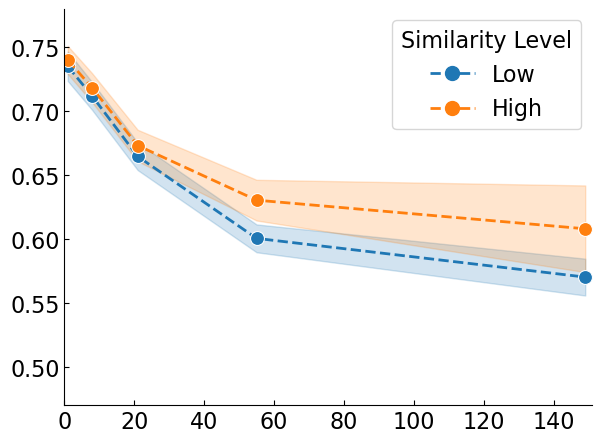

In [16]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_dprime, y="hr", x="log_lag_disp", hue="roll_cat_len_level", marker="o", markersize=10, linestyle="--", lw=2, ax=ax, errorbar="se")
plt.ylabel('P("Yes" | Old)')
plt.xlabel("Lag")
ax.set(xlabel=None, ylabel=None)
plt.xticks(ticks=np.arange(0, 160, 20))
plt.ylim([0.47, 0.78])
plt.xlim([0, 151])
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Low"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="High"),
]
plt.legend(handles=legend_elements, title="Similarity Level")

if SAVEFIG:
    plt.savefig(f"simu1_fig/simu1_David_hr.pdf")

#### FAR

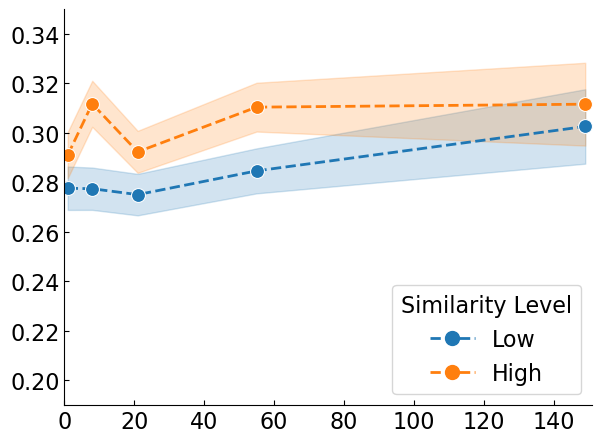

In [17]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_dprime, y="far", x="log_lag_disp", hue="roll_cat_len_level", marker="o", markersize=10, linestyle="--", lw=2, ax=ax, errorbar="se")
plt.ylabel('P("Yes" | New)')
plt.xlabel("Lag")
ax.set(xlabel=None, ylabel=None)
plt.xticks(ticks=np.arange(0, 160, 20))
plt.yticks(ticks=np.arange(0.14, 0.40, 0.02))
plt.ylim([0.19, 0.35])
plt.xlim([0, 151])
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Low"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="High"),
]
plt.legend(handles=legend_elements, title="Similarity Level", loc="lower right")

if SAVEFIG:
    plt.savefig(f"simu1_fig/simu1_David_far.pdf")

#### d prime

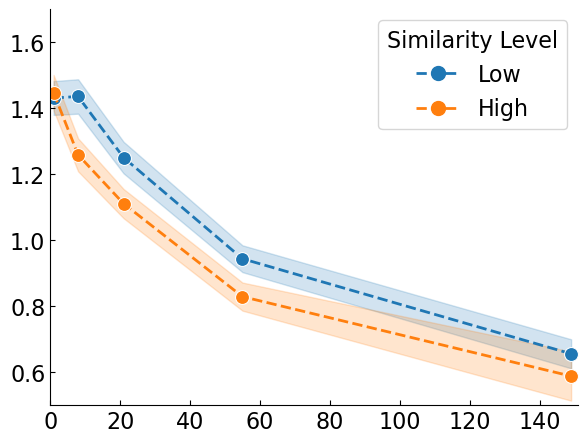

In [18]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_dprime, y="dprime", x="log_lag_disp", hue="roll_cat_len_level", marker="o", markersize=10, linestyle="--", lw=2, ax=ax, errorbar="se")
plt.ylabel("d prime")
plt.xlabel("Lag")
ax.set(xlabel=None, ylabel=None)
plt.xticks(ticks=np.arange(0, 160, 20))
plt.ylim([0.5, 1.7])
plt.xlim([0, 151])
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Low"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="High"),
]
plt.legend(handles=legend_elements, title="Similarity Level")

# if SAVEFIG:
#     plt.savefig(f"simu1_fig/simu1_David_dprime.pdf")

In [19]:
df_hrfar = df_dprime.groupby(["roll_cat_len_level", "log_lag_disp"])[["hr", "far"]].mean().reset_index()
hr_lowsim = df_hrfar.query('roll_cat_len_level == "0-1"').hr.to_numpy()
hr_highsim = df_hrfar.query('roll_cat_len_level == ">=2"').hr.to_numpy()
far_lowsim = df_hrfar.query('roll_cat_len_level == "0-1"').far.to_numpy()
far_highsim = df_hrfar.query('roll_cat_len_level == ">=2"').far.to_numpy()
hr_lowsim, hr_highsim, far_lowsim, far_highsim

(array([0.73528314, 0.71190804, 0.66474925, 0.60056249, 0.57024019]),
 array([0.74021639, 0.71836619, 0.6732462 , 0.630465  , 0.60805243]),
 array([0.27763631, 0.27743965, 0.27505591, 0.28464965, 0.3025976 ]),
 array([0.29104778, 0.31175592, 0.29234161, 0.3103968 , 0.31159807]))

In [20]:
df_dprime.groupby(["log_lag_disp", "roll_cat_len_level"])[["hr", "far", "dprime"]].mean().reset_index()

,log_lag_disp,roll_cat_len_level,hr,far,dprime
0,1.0,0-1,0.735283,0.277636,1.430662
1,1.0,>=2,0.740216,0.291048,1.446680
2,8.0,0-1,0.711908,0.277440,1.435350
3,8.0,>=2,0.718366,0.311756,1.258475
4,21.0,0-1,0.664749,0.275056,1.250304
5,21.0,>=2,0.673246,0.292342,1.110789
6,55.0,0-1,0.600562,0.284650,0.943656
7,55.0,>=2,0.630465,0.310397,0.828898
8,149.0,0-1,0.570240,0.302598,0.655572
9,149.0,>=2,0.608052,0.311598,0.587872


#### Az

In [21]:
def calculate_Az(df_tmp1):
    log_lag_bins = [0, 2, 3, 4, 5]
    Azs = []
    for bin in log_lag_bins:

        # get the df of this log_lag_bin
        col_name = "log_lag_bin_" + str(bin)
        df_tmp = df_tmp1.query(col_name + " == True").copy()

        # get variables
        conf = df_tmp.confidence.to_numpy()
        truth = df_tmp.old.to_numpy()
        old_num = np.sum(truth)
        new_num = np.sum(~truth)
        is_old = truth
        is_new = ~truth

        if old_num == 0 or new_num == 0:
            Azs.append(np.nan)
            continue

        min_conf = np.nanmin(conf)
        max_conf = np.nanmax(conf)

        if max_conf == min_conf:  ### need consider!
            Azs.append(np.nan)
            continue

        # calculate HR and FAR for different thresholds
        thresholds = np.arange(1, 8)
        # thresholds = np.arange(min_conf, max_conf+1)
        hrs = []
        fars = []
        old_conf = conf * is_old
        new_conf = conf * is_new
        for thresh in thresholds:
            # hr = (np.sum((conf > thresh) & is_old) + 0.5) / (old_num + 1)
            # far = (np.sum((conf > thresh) & is_new) + 0.5) / (new_num + 1)
            hr = (np.sum(old_conf > thresh) + 0.5) / (old_num + 1)
            far = (np.sum(new_conf > thresh) + 0.5) / (new_num + 1)
            hrs.append(hr)
            fars.append(far)

        # calculate z_hr and z_far
        z_hr = norm.ppf(hrs)
        z_far = norm.ppf(fars)

        # # linear regression on z_hr and z_far using sklearn
        # X = np.array(z_far).reshape(-1, 1)
        # y = np.array(z_hr)
        # reg = LinearRegression().fit(X, y)
        # # get slope and intercept
        # slope = reg.coef_[0]
        # intercept = reg.intercept_

        # linear regression on z_hr and z_far manually
        try:
            n = len(z_far)
            X = np.column_stack((np.ones(n), z_far))
            beta = np.linalg.inv(X.T @ X) @ X.T @ z_hr
            intercept, slope = beta
        except:
            Azs.append(np.nan)
            continue

        # get A_z
        Az = norm.cdf(intercept / np.sqrt(1 + slope**2))
        Azs.append(Az)

    # df to return
    df_return = pd.DataFrame({"log_lag_bin": log_lag_bins, "Az": Azs})

    return df_return

In [22]:
df_Az = df.groupby(["subject_ID", "roll_cat_len_level"]).apply(calculate_Az).reset_index()
df_Az.drop(columns="level_2", inplace=True)
df_Az["log_lag_disp"] = np.ceil(np.e**df_Az.log_lag_bin)
df_Az

,subject_ID,roll_cat_len_level,log_lag_bin,Az,log_lag_disp
0,0,0-1,0,0.960764,1.0
1,0,0-1,2,0.950700,8.0
2,0,0-1,3,0.933726,21.0
3,0,0-1,4,0.941136,55.0
4,0,0-1,5,NaN,149.0
...,...,...,...,...,...
5475,656,>=2,0,0.905277,1.0
5476,656,>=2,2,0.916667,8.0
5477,656,>=2,3,0.857943,21.0
5478,656,>=2,4,0.708139,55.0


In [23]:
# pickup those rows where Az is Nan in df_Az
df_Az.loc[df_Az.Az.isna()]

,subject_ID,roll_cat_len_level,log_lag_bin,Az,log_lag_disp
4,0,0-1,5,NaN,149.0
8,0,>=2,4,NaN,55.0
9,0,>=2,5,NaN,149.0
19,1,>=2,5,NaN,149.0
29,2,>=2,5,NaN,149.0
...,...,...,...,...,...
5414,650,0-1,5,NaN,149.0
5419,650,>=2,5,NaN,149.0
5429,651,>=2,5,NaN,149.0
5449,653,>=2,5,NaN,149.0


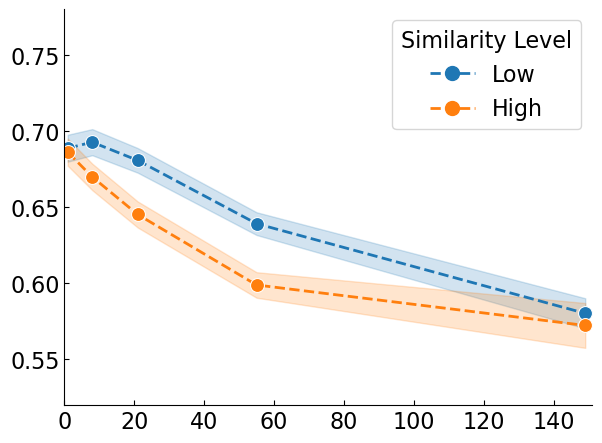

In [24]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_Az, y="Az", x="log_lag_disp", hue="roll_cat_len_level", marker="o", markersize=10, linestyle="--", lw=2, ax=ax, errorbar="se")
plt.ylabel("$A_z$")
plt.xlabel("Lag")
ax.set(xlabel=None, ylabel=None)
plt.yticks(ticks=np.arange(0.5, 0.80, 0.05))
plt.xticks(ticks=np.arange(0, 160, 20))
plt.ylim([0.52, 0.78])
plt.xlim([0, 151])
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="--", label="Low"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="--", label="High"),
]
plt.legend(handles=legend_elements, title="Similarity Level")

if SAVEFIG:
    plt.savefig(f"simu1_fig/simu1_David_Az.pdf")

In [25]:
df_plot = df_Az.groupby(["roll_cat_len_level", "log_lag_bin"]).Az.mean().to_frame(name="Az").reset_index()
Az_lowsim = df_plot.query("roll_cat_len_level == '0-1'").Az.to_numpy()
Az_highsim = df_plot.query("roll_cat_len_level == '>=2'").Az.to_numpy()
Az_lowsim, Az_highsim

(array([0.68868652, 0.6926573 , 0.68071234, 0.63916728, 0.58026331]),
 array([0.68610773, 0.6698682 , 0.64518625, 0.59889931, 0.57231558]))

In [26]:
# save for R
if SAVECSV:
    df_dprime.to_csv("simu1_data/simu1_David_hrfar.csv", index=False)
    df_Az.to_csv("simu1_data/simu1_David_Az.csv", index=False)

In [27]:
df

,rt,subject_ID,item,lag,category,confidence,category_label,position,old,yes,...,roll_cat_len_level,log_lag,log_lag_bin,log_lag_bin_newpre,log_lag_bin_newpost,log_lag_bin_0,log_lag_bin_2,log_lag_bin_3,log_lag_bin_4,log_lag_bin_5
20,812.780,0,FUDGE,0,Uncategorized,1.0,Desserts,20,False,0.0,...,0-1,-inf,NaN,N,2.0,False,True,False,False,False
21,829.330,0,LEMON,18,Uncategorized,1.0,Fruit,21,True,0.0,...,0-1,2.890372,2.0,N,N,False,True,False,False,False
22,911.690,0,GORILLA,0,Uncategorized,1.0,Zoo,22,False,0.0,...,0-1,-inf,NaN,2.0,2.0,False,True,False,False,False
23,1116.505,0,CROW,15,Birds,8.0,Birds,23,True,1.0,...,0-1,2.708050,2.0,N,N,False,True,False,False,False
24,1588.425,0,CALCULATOR,0,Uncategorized-Singleton,1.0,Electronics,24,False,0.0,...,0-1,-inf,NaN,2.0,0.0,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317835,1911.000,656,COLA,37,Beverages,2.0,Beverages,575,True,0.0,...,>=2,3.610918,3.0,N,N,False,False,True,False,False
317836,2358.000,656,BASEBALL,115,Toys,8.0,Toys,576,True,1.0,...,0-1,4.744932,4.0,N,N,False,False,False,True,False
317837,1239.000,656,TEA,24,Beverages,8.0,Beverages,577,True,1.0,...,>=2,3.178054,3.0,N,N,False,False,True,False,False
317838,1567.000,656,RADIO,41,Uncategorized-Singleton,2.0,Electronics,578,True,0.0,...,0-1,3.713572,3.0,N,N,False,False,True,False,False


In [28]:
df_csim = df.query("log_lag_bin_0 == True or log_lag_bin_2 == True or log_lag_bin_3 == True or log_lag_bin_4 == True or log_lag_bin_5 == True")

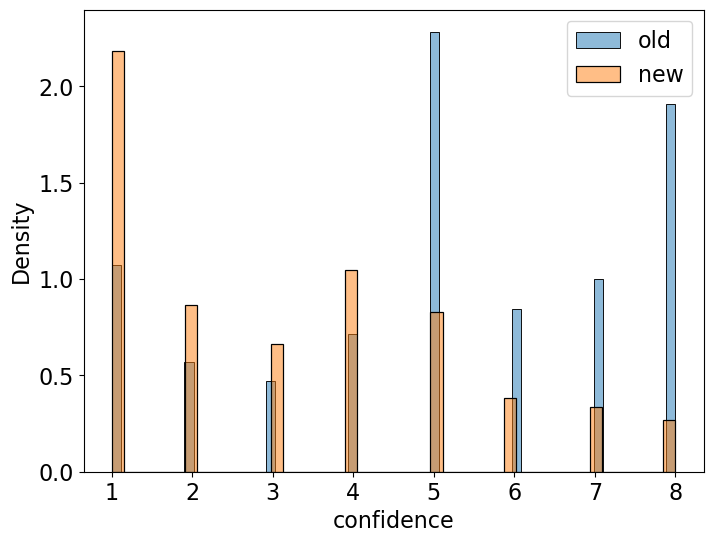

In [29]:
# plot histogram of csim, group by roll_cat_len_level and old
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(df.query("old == True"), x="confidence", alpha=0.5, ax=ax, stat="density", label="old")
sns.histplot(df.query("old == False"), x="confidence", alpha=0.5, ax=ax, stat="density", label="new")
plt.legend()
plt.show()